In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier # DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier # RandomForestRegressor

from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.cluster import KMeans

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA # Singular Value Decomposition

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
# from sklearn.

In [ ]:
from sklearn.datasets import load_digits

In [ ]:
dataset = load_digits()

In [ ]:
df_ld = pd.DataFrame(dataset.data, columns=dataset['feature_names'])

In [ ]:
df_ld.shape

(1797, 64)

In [ ]:
df_ld.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 64 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pixel_0_0  1797 non-null   float64
 1   pixel_0_1  1797 non-null   float64
 2   pixel_0_2  1797 non-null   float64
 3   pixel_0_3  1797 non-null   float64
 4   pixel_0_4  1797 non-null   float64
 5   pixel_0_5  1797 non-null   float64
 6   pixel_0_6  1797 non-null   float64
 7   pixel_0_7  1797 non-null   float64
 8   pixel_1_0  1797 non-null   float64
 9   pixel_1_1  1797 non-null   float64
 10  pixel_1_2  1797 non-null   float64
 11  pixel_1_3  1797 non-null   float64
 12  pixel_1_4  1797 non-null   float64
 13  pixel_1_5  1797 non-null   float64
 14  pixel_1_6  1797 non-null   float64
 15  pixel_1_7  1797 non-null   float64
 16  pixel_2_0  1797 non-null   float64
 17  pixel_2_1  1797 non-null   float64
 18  pixel_2_2  1797 non-null   float64
 19  pixel_2_3  1797 non-null   float64
 20  pixel_2_

In [ ]:
df_ld['target'] = dataset.get('target',[])

In [ ]:
df_ld['target'][0]

np.int64(0)

In [ ]:
# dataset.data.shape
df_ld

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9


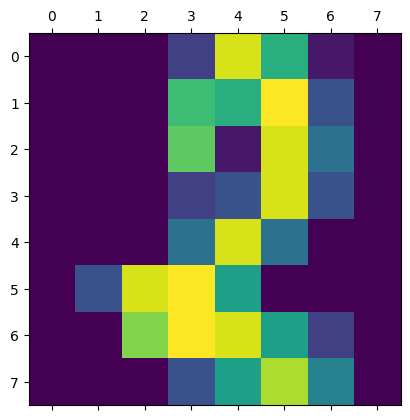

In [ ]:
plt.matshow(np.array(df_ld.iloc[51,:-1]).reshape(8,8))
plt.show()

In [ ]:
df_ld.loc[51, 'target']

np.int64(2)

In [ ]:
ss = StandardScaler()
ld_scaled = ss.fit_transform(df_ld.iloc[:,:-1])

In [ ]:
ld_cov = np.cov(ld_scaled.T)

In [ ]:
np.min(ld_cov)

np.float64(-0.570513633238107)

In [ ]:
eval,evec = np.linalg.eig(ld_cov)

In [ ]:
len(evec)

64

In [ ]:
tot_var = np.sum(eval)
exp_var = [ v / tot_var * 100 for v in sorted(eval, reverse=False)]

In [ ]:
np.cumsum(eval)

array([ 7.34477606, 13.1802666 , 18.33422778, 22.30046374, 25.26680894,
       27.83885336, 30.24486277, 32.31353632, 34.14346946, 35.93298685,
       37.63083301, 39.2037119 , 40.59241971, 41.9517558 , 43.27328116,
       44.44157292, 45.5252597 , 46.52503832, 47.49942125, 48.40833366,
       49.23105293, 50.00736307, 50.71891982, 51.36444347, 51.95971746,
       52.53621925, 53.06295081, 53.57358711, 54.06045092, 54.51605199,
       54.95890354, 55.38120441, 55.78031071, 56.17141182, 56.53235699,
       56.88096005, 57.20055635, 57.49462262, 57.77154547, 57.82191991,
       57.88520952, 58.14348253, 58.39131281, 58.63366941, 58.71002336,
       58.79249148, 58.88267691, 58.98108567, 59.08359001, 59.19547656,
       59.31480554, 59.43906925, 59.57228006, 59.71539433, 59.93297633,
       60.09116107, 60.25991343, 60.46790936, 60.6440383 , 60.8441292 ,
       61.03396437, 61.03396437, 61.03396437, 61.03396437])

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca_model = PCA(n_components=33)

In [ ]:
ld_pca = pca_model.fit_transform(ld_scaled)

In [ ]:
pca_model.explained_variance_ratio_.max()

np.float64(0.12033916097734909)